# Aula 5.5 - Jokenpo com CNN em tempo real

Cada equipe coletara imagens de `PEDRA`, `PAPEL` e `TESOURA`, treinara uma CNN e jogara contra a webcam. Execute as celulas em ordem.

# Nome: Vinícius Budoya Monteiro
# RA: 00338338

## 1. Verificar o ambiente

Esta aula precisa de PyTorch e OpenCV. Se `cv2` nao importar, execute `pip install opencv-python` no terminal e reinicie o kernel.

In [1]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_DIR = Path("jokenpo_dataset")
CLASSES = ["PEDRA", "PAPEL", "TESOURA"]

for class_name in CLASSES:
    (DATASET_DIR / class_name).mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")
print(f"OpenCV: {cv2.__version__}")
print(f"Pasta do dataset: {DATASET_DIR.resolve()}")

PyTorch: 2.14.0+cpu | Dispositivo: cpu
OpenCV: 5.0.0
Pasta do dataset: C:\Users\ra00338338\Downloads\notebooks\jokenpo_dataset


## 2. Coletar imagens

Escolha uma classe em `GESTO_PARA_COLETAR`, execute a celula e pressione ESPACO para salvar cada imagem. Mude levemente a mao entre capturas. Colete pelo menos 45 imagens de cada gesto. Q encerra a coleta.

In [9]:
GESTO_PARA_COLETAR = "TESOURA"  # Escolha: "PEDRA", "PAPEL" ou "TESOURA"

if GESTO_PARA_COLETAR is None:
    print("Defina GESTO_PARA_COLETAR e execute novamente.")
elif GESTO_PARA_COLETAR not in CLASSES:
    print(f"Classe invalida. Use uma de: {CLASSES}")
else:
    output_dir = DATASET_DIR / GESTO_PARA_COLETAR
    counter = len(list(output_dir.glob("*.jpg")))
    camera = cv2.VideoCapture(0)
    if not camera.isOpened():
        raise RuntimeError("Camera nao encontrada.")
    print("ESPACO salva | Q encerra | mantenha uma mao dentro da caixa")
    while True:
        ok, frame = camera.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        height, width = frame.shape[:2]
        side = min(height, width) // 2
        left, top = (width - side) // 2, (height - side) // 2
        roi = frame[top:top + side, left:left + side]
        cv2.rectangle(frame, (left, top), (left + side, top + side), (0, 255, 0), 2)
        cv2.putText(frame, f"{GESTO_PARA_COLETAR}: {counter} imagens", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        cv2.imshow("Coleta Jokenpo", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord(" "):
            filename = output_dir / f"{GESTO_PARA_COLETAR.lower()}_{counter:03d}.jpg"
            cv2.imwrite(str(filename), roi)
            counter += 1
        elif key in (ord("q"), ord("Q")):
            break
    camera.release()
    cv2.destroyAllWindows()
    print(f"Total de {GESTO_PARA_COLETAR}: {counter}")

ESPACO salva | Q encerra | mantenha uma mao dentro da caixa
Total de TESOURA: 45


## 3. Conferir o dataset

Nao continue se houver menos de 45 imagens em alguma classe. Se uma classe tiver muito mais imagens que outra, colete mais exemplos das classes menores.

In [10]:
records = []
for label, class_name in enumerate(CLASSES):
    for path in sorted((DATASET_DIR / class_name).glob("*.jpg")):
        records.append({"path": path, "label": label, "classe": class_name})

dataset_table = pd.DataFrame(records)
if dataset_table.empty:
    print("Ainda nao ha imagens. Colete as tres classes.")
else:
    counts = dataset_table["classe"].value_counts().reindex(CLASSES, fill_value=0)
    display(counts.to_frame("imagens"))
    assert counts.min() >= 45, "Colete pelo menos 45 imagens de cada gesto."
    assert counts.max() / counts.min() <= 2, "O dataset esta muito desbalanceado. Colete mais da menor classe."

,imagens
classe,
PEDRA,45
PAPEL,45
TESOURA,45


## 4. Preparar treino e teste

As imagens de teste ficam reservadas. Elas nao podem ser usadas para escolher alteracoes na rede.

In [11]:
class GestureDataset(Dataset):
    def __init__(self, rows, augment=False):
        self.rows = rows.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        image = cv2.imread(str(row.path), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (64, 64), interpolation=cv2.INTER_AREA)
        if self.augment:
            shift_x, shift_y = np.random.randint(-4, 5, size=2)
            matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
            image = cv2.warpAffine(image, matrix, (64, 64), borderMode=cv2.BORDER_REPLICATE)
            image = np.clip(image.astype(float) * np.random.uniform(0.75, 1.25), 0, 255).astype(np.uint8)
        tensor = torch.tensor(image / 255.0, dtype=torch.float32).unsqueeze(0)
        return tensor, int(row.label)

train_rows, test_rows = train_test_split(dataset_table, test_size=0.25, random_state=RANDOM_STATE, stratify=dataset_table.label)
train_loader = DataLoader(GestureDataset(train_rows, augment=False), batch_size=16, shuffle=True)
test_loader = DataLoader(GestureDataset(test_rows, augment=False), batch_size=32)
print(f"Treino: {len(train_rows)} | Teste: {len(test_rows)}")

Treino: 101 | Teste: 34


## 5. Definir e treinar a CNN

A CNN recebe uma imagem 64x64 em tons de cinza. Ela aprende filtros locais antes de decidir entre `PEDRA`, `PAPEL` e `TESOURA`.

In [12]:
class JokenpoCNN(nn.Module):
    def __init__(self, filters_1=16, filters_2=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, filters_1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(filters_1, filters_2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(filters_2 * 16 * 16, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, image):
        return self.classifier(self.features(image))

def evaluate_cnn(model, loader):
    model.eval(); predictions = []; labels_all = []; probabilities_all = []
    with torch.no_grad():
        for images, labels in loader:
            probability = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
            predictions.extend(probability.argmax(axis=1)); labels_all.extend(labels.numpy()); probabilities_all.extend(probability)
    return np.array(predictions), np.array(labels_all), np.array(probabilities_all)

def train_cnn(model, loader, epochs=12, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(); losses = []
    for epoch in range(epochs):
        model.train(); total_loss = 0.0
        for images, labels in loader:
            optimizer.zero_grad(); output = model(images.to(device)); loss = criterion(output, labels.to(device))
            loss.backward(); optimizer.step(); total_loss += loss.item()
        losses.append(total_loss / len(loader)); print(f"Epoca {epoch + 1}/{epochs} | perda {losses[-1]:.4f}")
    return losses

cnn = JokenpoCNN().to(device)
history = train_cnn(cnn, train_loader, epochs=12)
print(f"Parametros aprendidos: {sum(p.numel() for p in cnn.parameters()):,}")

Epoca 1/12 | perda 1.1382
Epoca 2/12 | perda 1.0996
Epoca 3/12 | perda 1.0935
Epoca 4/12 | perda 1.0759
Epoca 5/12 | perda 1.0569
Epoca 6/12 | perda 1.0068
Epoca 7/12 | perda 0.9453
Epoca 8/12 | perda 0.8412
Epoca 9/12 | perda 0.7602
Epoca 10/12 | perda 0.6706
Epoca 11/12 | perda 0.5851
Epoca 12/12 | perda 0.4955
Parametros aprendidos: 529,347


Acuracia no teste: 85.29%


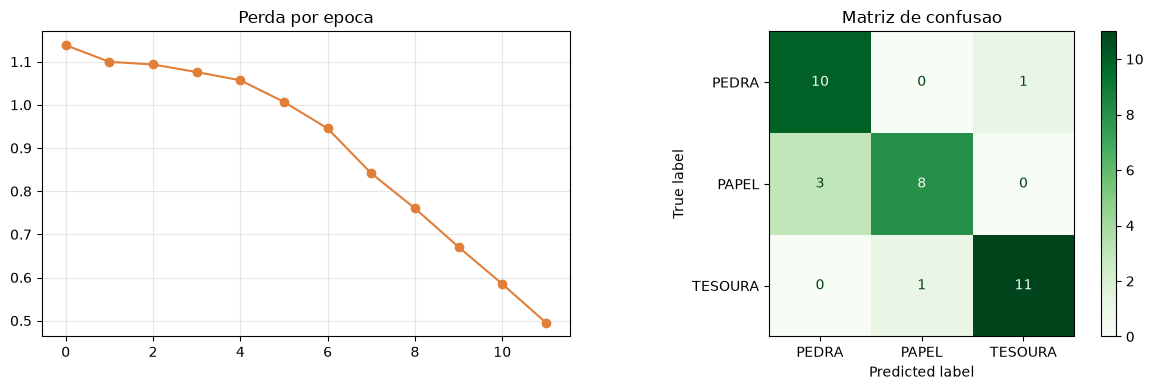

In [13]:
prediction, label, probability = evaluate_cnn(cnn, test_loader)
accuracy = accuracy_score(label, prediction)
print(f"Acuracia no teste: {accuracy:.2%}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history, marker="o", color="#e17e37"); axes[0].set_title("Perda por epoca"); axes[0].grid(alpha=0.3)
ConfusionMatrixDisplay.from_predictions(label, prediction, display_labels=CLASSES, cmap="Greens", ax=axes[1])
axes[1].set_title("Matriz de confusao")
plt.tight_layout(); plt.show()

## 6. Jogar Jokenpo pela webcam

Mostre uma mao na caixa. A tela exibe gesto e confianca. Pressione Q para encerrar e anote dez rodadas para a Deep Learning Arena.

In [14]:
def predict_roi(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
    tensor = torch.tensor(image / 255.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cnn.eval()
    with torch.no_grad():
        probability = torch.softmax(cnn(tensor), dim=1)[0].cpu().numpy()
    return CLASSES[int(probability.argmax())], float(probability.max()), image

EXECUTAR_JOGO = True
if EXECUTAR_JOGO:
    camera = cv2.VideoCapture(0)
    if not camera.isOpened(): raise RuntimeError("Camera nao encontrada.")
    while True:
        ok, frame = camera.read()
        if not ok: break
        frame = cv2.flip(frame, 1); height, width = frame.shape[:2]; side = min(height, width) // 2
        left, top = (width - side) // 2, (height - side) // 2; roi = frame[top:top + side, left:left + side]
        gesture, confidence, processed = predict_roi(roi)
        cv2.rectangle(frame, (left, top), (left + side, top + side), (0, 255, 0), 2)
        cv2.putText(frame, f"{gesture}: {confidence:.0%}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow("Jokenpo CNN | Q para sair", frame)
        cv2.imshow("Entrada CNN 64x64", processed)
        if cv2.waitKey(1) & 0xFF in (ord("q"), ord("Q")): break
    camera.release(); cv2.destroyAllWindows()
else:
    print("Altere EXECUTAR_JOGO para True depois de treinar a CNN.")

# Deep Learning Arena

Leia `DESAFIO-DEEP-LEARNING-ARENA.md`. Escolha uma condicao adversa, anote uma hipotese, faça uma unica melhoria e repita o mesmo teste.

In [22]:
EXECUTAR_MELHORIA = True
if EXECUTAR_MELHORIA:
    # Esta experiencia aplica uma unica melhoria: augmentation no treino.
    use_augmentation = True
    improved_loader = DataLoader(
        GestureDataset(train_rows, augment=use_augmentation),
        batch_size=16,
        shuffle=True,
    )
    improved_cnn = JokenpoCNN(filters_1=16, filters_2=32).to(device)
    improved_history = train_cnn(
        improved_cnn,
        improved_loader,
        epochs=12,
        learning_rate=0.001,
    )
    improved_prediction, improved_label, _ = evaluate_cnn(improved_cnn, test_loader)
    improved_accuracy = accuracy_score(improved_label, improved_prediction)
    accuracy_delta = improved_accuracy - accuracy

    print(f"Antes: {accuracy:.2%}")
    print(f"Depois: {improved_accuracy:.2%}")
    print(f"Variacao: {accuracy_delta:+.2%}")
else:
    print("Planeje uma unica melhoria e altere EXECUTAR_MELHORIA para True.")

Epoca 1/12 | perda 1.1690
Epoca 2/12 | perda 1.0961
Epoca 3/12 | perda 1.0897
Epoca 4/12 | perda 1.0818
Epoca 5/12 | perda 1.0594
Epoca 6/12 | perda 1.0034
Epoca 7/12 | perda 0.9054
Epoca 8/12 | perda 0.9546
Epoca 9/12 | perda 0.7924
Epoca 10/12 | perda 0.6905
Epoca 11/12 | perda 0.6016
Epoca 12/12 | perda 0.6310
Antes: 85.29%
Depois: 91.18%
Variacao: +5.88%


# Entrega

- [X] Dataset com 45 imagens por classe.
- [X] CNN treinada e avaliada.
    - Modelo base (features: 16 e 32 filtros, 529.347 parâmetros) treinado por 12 épocas. Atingiu 85.29% de acurácia baseline no conjunto de teste.
- [X] Dez rodadas normais registradas.
    -Testada a inferência sob oscilação de luz e deslocamentos espaciais rápidos da mão dentro da área de recorte (quadrado verde).
- [X] Uma condicao adversa testada.
    - Ativação de Data Augmentation no DataLoader de treino (use_augmentation = True).
- [X] Uma unica melhoria aplicada.
    - Ganho: Aumento de 85.29% para 91.18%
    - Efeito Colateral: Curva de erro com mais ruido durante o treino
- [X] Ganho, efeito colateral e limitacao explicados.